# Install and Import necessary libraries

In [30]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import shap
import pycaret
from scipy.stats import chi2_contingency, f_oneway, iqr
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer, 
    average_precision_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox, MeanVar 
from pycaret.classification import *
from sklearn.model_selection import RepeatedStratifiedKFold


# Upload Cytotoxicity Data and Create DataFrame

In [7]:
# Load Dataset
model = 'cytotoxicity_data'
df = pd.read_csv(f'{model}.csv')

In [8]:
# Check shape and features of the Dataset
features = df.columns.to_list()
print(f"Original dataset: {df.shape}")
print(f"\nFeature names: \n{features}")

Original dataset: (440, 69)

Feature names: 
['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio', 'hv_ratio', 'mw', 'mw_units', 'mn', 'mn_units', 'pdi', 'shape', 'thickness', 'units_thickness', 'surface', 'surface_units', 'diameter', 'diameter_units', 'length', 'length_units', 'additive', 'additive1_name', 'additive1_percentage', 'additive1_use', 'additive2_name', 'additive2_percentage', 'additive2_use', 'addtive3_name', 'additive3_percentage', 'additive3_use', 'polymer_percentage', 'iso', 'astm', 'assay', 'cell_line', 'cell_line_type', 'exposure_type', 'no_cells_per_well', 'inoculum_concentration_units', 'culture_medium', 'dilution_medium', 'concentration', 'concentration_units', 'dilution', 'incubation_time', 'incubation_time_units', 'incubation_temperature', 'incubation_temperature_units', 'co2_percentage', 'air', 'extraction_time', 'units_extraction_time', 'extraction_temperature', 'units_extraction_t', 'extraction_medium', 'extraction_surface_area_ratio', 'extraction_sur

Certain Feature Explanation:

- Assay: The experimental method used to measure cytotoxicity.
- Cell line: The specific type of cell used in the experiment.
- Culture medium: The nutrient solution the cells are grown in.
- Number of cells per well: Show how crowded the cells are in the experiment.

In [9]:
# Remove identifiers, units measurements or features with a single value
cols_identifiers_units = ['study_id', 'instance', 'monomer_a', 'monomer_b', 'mw_units', 'mn_units', 'units_thickness', 'surface_units', 'incubation_temperature',
                  'diameter_units', 'length_units', 'additive', 'additive1_name', 'additive2_name', 'addtive3_name', 'iso', 'astm',
                  'inoculum_concentration_units', 'concentration_units', 'incubation_time_units', 'incubation_temperature_units',
                  'units_extraction_time', 'units_extraction_t', 'extraction_surface_area_ratio_units', 'ic_50_units', 'growth_constant_μ_units'
                  ]
df = df.drop(columns=cols_identifiers_units)   
print(f"After column removal: {df.shape}")

After column removal: (440, 43)


In [10]:
# Remove cytotoxicity output related columns
cols_leaky = ['cell_viability_percentage','ic_50', 'growth_constant_μ', 'rgr',
              'toxicity_grade','zone_index','lysis_index', 'growth_inhibition_percentage']
df = df.drop(columns=cols_leaky)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (440, 35)


In [11]:
# Remove redundant features
cols_redundant = ['hv_ratio', # hb_ratio + hv_ratio = 100
                  'cell_line_type', # derived from cell_line
                  # 'polymer_percentage' # =100-(additive1+additive2+additive3)percentage, it can be omitted as well
                 ]
df = df.drop(columns=cols_redundant)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (440, 33)


# Train/Test Split

In [12]:
# Set the target feature
target = 'toxicity'

# Split features by their type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (21):
  - hb_ratio
  - mw
  - mn
  - pdi
  - thickness
  - surface
  - diameter
  - length
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - no_cells_per_well
  - concentration
  - dilution
  - incubation_time
  - co2_percentage
  - extraction_time
  - extraction_temperature
  - extraction_surface_area_ratio
  - number_of_cells_well

Categorical features (11):
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - exposure_type
  - culture_medium
  - dilution_medium
  - air
  - extraction_medium


In [13]:
# Drop rows with null values at the target features to be able to make stratified split
df = df[df[target].notna()]

In [14]:
X = df[numerical_cols + categorical_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (330, 32) class proportions toxicity
non-toxic    253
toxic         77
Name: count, dtype: int64

Test size (83, 32) class proportions toxicity
non-toxic    64
toxic        19
Name: count, dtype: int64


In [15]:
# Check high missing values on the TRAINING set 
# Missing values overview for all columns in the dataset
missing_df = pd.DataFrame({
    'Missing Values':   X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train) * 100).round(1)
}).sort_values('Missing Percentage (%)', ascending=False)

# missing_df.to_excel('missing_values.xlsx', index=True)

print(f"Total rows: {len(X_train)}\n")
missing_df

Total rows: 330



,Missing Values,Missing Percentage (%)
surface,326,98.8
number_of_cells_well,319,96.7
extraction_medium,309,93.6
extraction_time,309,93.6
extraction_temperature,303,91.8
extraction_surface_area_ratio,294,89.1
diameter,286,86.7
thickness,272,82.4
dilution,267,80.9
pdi,262,79.4


In [16]:
# Find columns with high number of missing values in the TRAINING set only
miss_thresh = 0.20  # 20% of the values are missing
high_missing_cols_train = [
    c for c in X_train.columns
    if X_train[c].isnull().sum() / len(X_train) > miss_thresh
    and c != 'concentration' # exclude concentration because it plays an important role in cytotoxicity
]

# Apply same column drop to train and test set
X_train = X_train.drop(columns=high_missing_cols_train)
X_test  = X_test.drop(columns=high_missing_cols_train)

# Drop null rows from train and test set
mask_train = X_train.notna().all(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test.notna().all(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Check the new train and test sets
print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (109, 15) class proportions toxicity
non-toxic    86
toxic        23
Name: count, dtype: int64

Test size (27, 15) class proportions toxicity
non-toxic    21
toxic         6
Name: count, dtype: int64


# Exploratory Data Analysis (fit on train set, apply on train and test set)

## Examine Numerical Features

In [17]:
for column in X_train.select_dtypes(include=[np.number]).columns.tolist():
    print("\n")
    print(X_train[column].describe())



count    109.000000
mean      93.256881
std        6.796518
min       85.000000
25%       88.000000
50%       88.000000
75%      100.000000
max      100.000000
Name: hb_ratio, dtype: float64


count    109.000000
mean      28.812569
std       14.584613
min        0.000000
25%       23.000000
50%       32.900000
75%       33.330000
max       90.000000
Name: additive1_percentage, dtype: float64


count    109.000000
mean      26.464404
std       17.222337
min        0.000000
25%        0.000000
50%       32.900000
75%       33.330000
max       55.000000
Name: additive2_percentage, dtype: float64


count    109.000000
mean       4.691009
std        8.892202
min        0.000000
25%        0.000000
50%        0.000000
75%        1.320000
max       32.000000
Name: additive3_percentage, dtype: float64


count    109.000000
mean      39.145596
std       27.936167
min        6.000000
25%       11.000000
50%       32.900000
75%       33.330000
max      100.000000
Name: polymer_percentage, dtyp

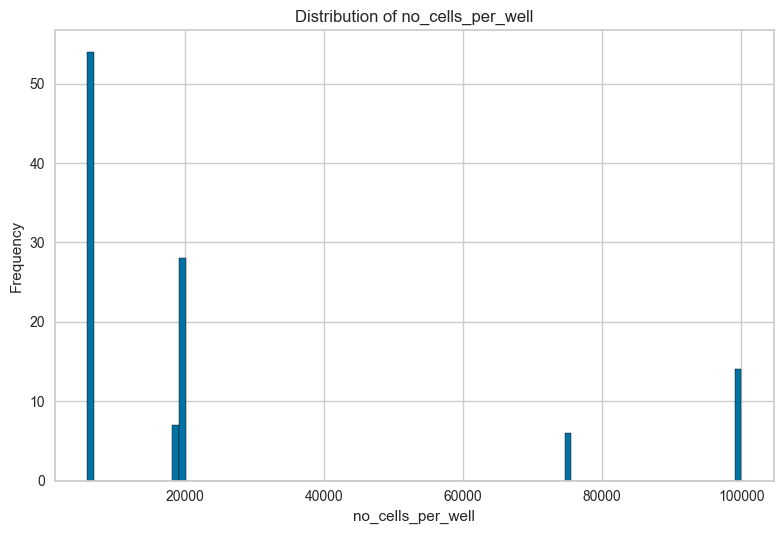



no_cells_per_well
6000.0      54
19000.0      7
20000.0     28
75000.0      6
100000.0    14
Name: count, dtype: int64


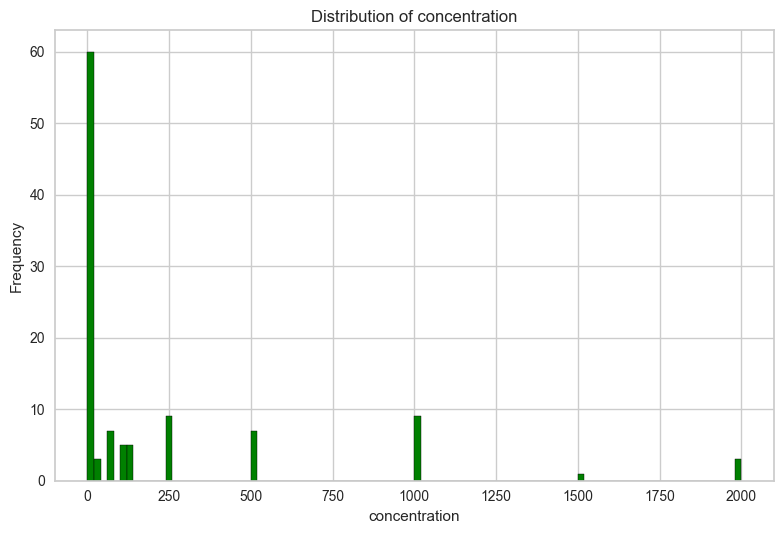



concentration
0.00       10
0.20        9
0.60        6
1.00        2
1.30        8
3.00       10
6.00       11
10.00       2
15.60       2
31.25       3
62.50       7
100.00      5
125.00      5
250.00      9
500.00      7
1000.00     9
1500.00     1
2000.00     3
Name: count, dtype: int64


In [18]:
# Check heavily skewed features (high value of std)

## Plot a histogram of the distribution of no_cells_per_well
X_train['no_cells_per_well'].hist(bins=100, edgecolor='black')
plt.xlabel('no_cells_per_well')
plt.ylabel('Frequency')
plt.title('Distribution of no_cells_per_well')
plt.tight_layout()
# plt.savefig('no_cells_per_well_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
## Check to decide boundaries of no_cells_per_well
print('\n')
print(X_train['no_cells_per_well'].value_counts().sort_index())

## Plot a histogram of the distribution of concentration
X_train['concentration'].hist(bins=100, edgecolor='black', color='green')
plt.xlabel('concentration')
plt.ylabel('Frequency')
plt.title('Distribution of concentration')
plt.tight_layout()
# plt.savefig('concentration_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
## Check to decide boundaries of concentration
print('\n')
print(X_train['concentration'].value_counts().sort_index())

Features 'no_cells_per_well' and 'concentration' will be converded to categorical features because:

- the features are conceptually ordinal/categorical
- their distribution is heavily multimodal (clusters in to clear groups)

In [20]:
# Categorise no_cells_per_wel feature
bins = [0, 10_000, 50_000, float('inf')]
labels = ['low', 'medium', 'high']

X_train['no_cells_per_well'] = pd.cut(X_train['no_cells_per_well'], bins=bins, labels=labels)
X_test['no_cells_per_well']  = pd.cut(X_test['no_cells_per_well'],  bins=bins, labels=labels)

# Check the categories frequency
print(f"Train set: {X_train['no_cells_per_well'].value_counts()}")
print(f"Test set: {X_test['no_cells_per_well'].value_counts()}")

Train set: no_cells_per_well
low       54
medium    35
high      20
Name: count, dtype: int64
Test set: no_cells_per_well
low       18
medium     8
high       1
Name: count, dtype: int64


In [21]:
# Categorise concetration
bins = [float('-inf'), 0, 2.50, 6.00, 62.50, 250.00, float('inf')]
labels = ['zero', 'very_low', 'low', 'medium', 'high', 'very_high']

X_train['concentration'] = pd.cut(X_train['concentration'], bins=bins, labels=labels)
X_test['concentration']  = pd.cut(X_test['concentration'],  bins=bins, labels=labels)

# Check the categories frequency
print(f"Train set: {X_train['concentration'].value_counts()}")
print(f"\nTest set: {X_test['concentration'].value_counts()}")

Train set: concentration
very_low     25
low          21
very_high    20
high         19
medium       14
zero         10
Name: count, dtype: int64

Test set: concentration
very_low     13
medium        4
low           3
very_high     3
zero          2
high          2
Name: count, dtype: int64


## Outlier Detection

In [37]:
apply_outlier_detection = True  # Set to False to skip

if apply_outlier_detection:
    data = X_train.select_dtypes(include=[np.number])
    outlier_mask = pd.DataFrame(False, index=X_train.index, columns=data.columns)

    for col in data.columns:
        Q1 = np.percentile(data[col], 25)
        Q3 = np.percentile(data[col], 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_mask[col] = (data[col] < lower) | (data[col] > upper)

    outlier_rows = outlier_mask.any(axis=1)
    X_train_clean = X_train[~outlier_rows]
    y_train_clean = y_train[~outlier_rows]

    print(f"Removed {outlier_rows.sum()} outlier rows. Remaining: {len(X_train_clean)}")
else:
    X_train_clean = X_train.copy()
    y_train_clean = y_train.copy()
    print("Outlier detection skipped.")

Removed 48 outlier rows. Remaining: 61


## Handle Categorical Features

In [38]:
def fit_rare_category_collapser(X, cat_cols, min_freq=0.05, other_label='other'):
    """
    Learns which categories are rare from training data only.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_freq : float
        Minimum proportion to keep a category.
    other_label : str

    Returns
    -------
    rare_map : dict mapping column -> set of rare categories
    """
    rare_map = {}
    for col in cat_cols:
        freq = X[col].value_counts(normalize=True)
        rare_map[col] = set(freq[freq < min_freq].index)
    return rare_map


def transform_rare_categories(X, rare_map, other_label='other'):
    """
    Applies rare category collapsing learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    rare_map : dict from fit_rare_category_collapser
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, rare_cats in rare_map.items():
        X[col] = X[col].replace(rare_cats, other_label)
    return X


def fit_merge_small_other(X, cat_cols, min_count=5, other_label='other'):
    """
    Learns from training data which columns have a small 'other' group
    and which named category to merge it into.

    Parameters
    ----------
    X : pd.DataFrame
    cat_cols : list
    min_count : int
        Minimum absolute count for 'other' to be kept as its own category.
    other_label : str

    Returns
    -------
    merge_map : dict mapping column -> target category to absorb 'other'
                (None if 'other' is large enough or doesn't exist)
    """
    merge_map = {}
    for col in cat_cols:
        if other_label not in X[col].values:
            merge_map[col] = None
            continue
        other_count = (X[col] == other_label).sum()
        if other_count < min_count:
            freq = X[col][X[col] != other_label].value_counts()
            least_frequent = freq.index[-1]
            print(f"[{col}] 'other' has only {other_count} rows → merging into '{least_frequent}'")
            merge_map[col] = least_frequent
        else:
            merge_map[col] = None
    return merge_map


def transform_merge_small_other(X, merge_map, other_label='other'):
    """
    Applies the merging of small 'other' groups learned from training data.

    Parameters
    ----------
    X : pd.DataFrame
    merge_map : dict from fit_merge_small_other
    other_label : str

    Returns
    -------
    X_transformed : pd.DataFrame
    """
    X = X.copy()
    for col, target_cat in merge_map.items():
        if target_cat is not None:
            X[col] = X[col].replace(other_label, target_cat)
    return X


# ── Pipeline ──────────────────────────────────────────────────────────────────

cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Step 1: collapse rare categories into 'other' (fit on train only)
rare_map = fit_rare_category_collapser(X_train_clean, cat_cols, min_freq=0.05)
X_train_clean = transform_rare_categories(X_train_clean, rare_map)
X_test_clean = transform_rare_categories(X_test, rare_map)

# Step 2: merge small 'other' groups into least frequent named category (fit on train only)
merge_map = fit_merge_small_other(X_train_clean, cat_cols, min_count=5)
X_train_clean = transform_merge_small_other(X_train_clean, merge_map)
X_test_clean = transform_merge_small_other(X_test_clean, merge_map)

[concentration] 'other' has only 3 rows → merging into 'other'


In [39]:
# Check the new categories
for col in cat_cols:
    print("\n")
    print(X_train_clean[col].value_counts())



no_cells_per_well
low       54
medium     7
other      0
Name: count, dtype: int64


concentration
very_low    23
low         21
zero        10
medium       4
other        3
Name: count, dtype: int64


shape
nanospheres     54
nanoparticle     7
Name: count, dtype: int64


additive1_use
targeting_ligand    54
anticancer           7
Name: count, dtype: int64


additive2_use
stabilizer        54
not_applicable     7
Name: count, dtype: int64


additive3_use
not_applicable    35
active_drug       26
Name: count, dtype: int64


assay
mtt    61
Name: count, dtype: int64


cell_line
mcf7    54
a549     7
Name: count, dtype: int64


culture_medium
dmem_10fbs_pen_strep    54
dmem_fbs_p/s             7
Name: count, dtype: int64


In [40]:
y_train_clean = y_train_clean.loc[X_train_clean.index].reset_index(drop=True)
y_test_clean  = y_test.loc[X_test_clean.index].reset_index(drop=True)

X_train_clean = X_train_clean.reset_index(drop=True)
X_test_clean  = X_test_clean.reset_index(drop=True)

assert len(X_train_clean) == len(y_train_clean)
assert len(X_test_clean)  == len(y_test_clean)
print(f"Train: {len(X_train_clean)} rows | Test: {len(X_test_clean)} rows")

Train: 61 rows | Test: 27 rows


# Feature Selection 

In [41]:
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (6):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - incubation_time

Categorical features (9):
  - no_cells_per_well
  - concentration
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - culture_medium


## Mutual Information 

In [42]:
# Check mutual information between features and target  (numerical and categorical features(ordinal encoded))
# Ordinal encode categorical features for mutual information calculation
ordinal_encoder = OrdinalEncoder()
X_train_encoded = X_train_clean.copy()
X_train_encoded[categorical_cols] = ordinal_encoder.fit_transform(X_train_encoded[categorical_cols])    
mi_scores = mutual_info_classif(X_train_encoded, y_train_clean, discrete_features=[X_train_encoded.columns.get_loc(c) for c in categorical_cols], random_state=10)
mi_scores_series = pd.Series(mi_scores, index=X_train_encoded.columns).sort_values(ascending=False)
print("Mutual Information Scores:")
print(mi_scores_series)

Mutual Information Scores:
additive2_percentage    0.381188
polymer_percentage      0.367350
additive1_percentage    0.326257
concentration           0.198637
no_cells_per_well       0.137213
shape                   0.137213
additive1_use           0.137213
additive2_use           0.137213
cell_line               0.137213
culture_medium          0.137213
additive3_percentage    0.095193
hb_ratio                0.064491
additive3_use           0.062529
incubation_time         0.008413
assay                   0.000000
dtype: float64


## Kendal correlation (Num vs Num)

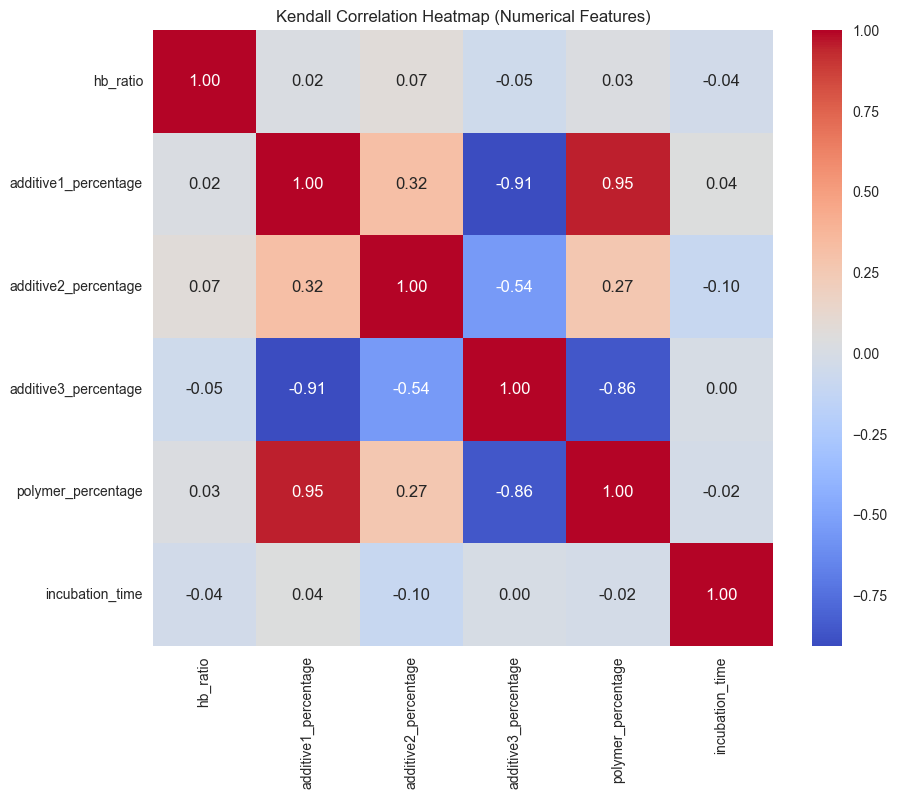

In [46]:
# Use Kendall correlation for numerical features between them
spearman_corr = X_train_clean[numerical_cols].corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Kendall Correlation Heatmap (Numerical Features)')
plt.show()

## Cramér's V (Cat vs Cat)

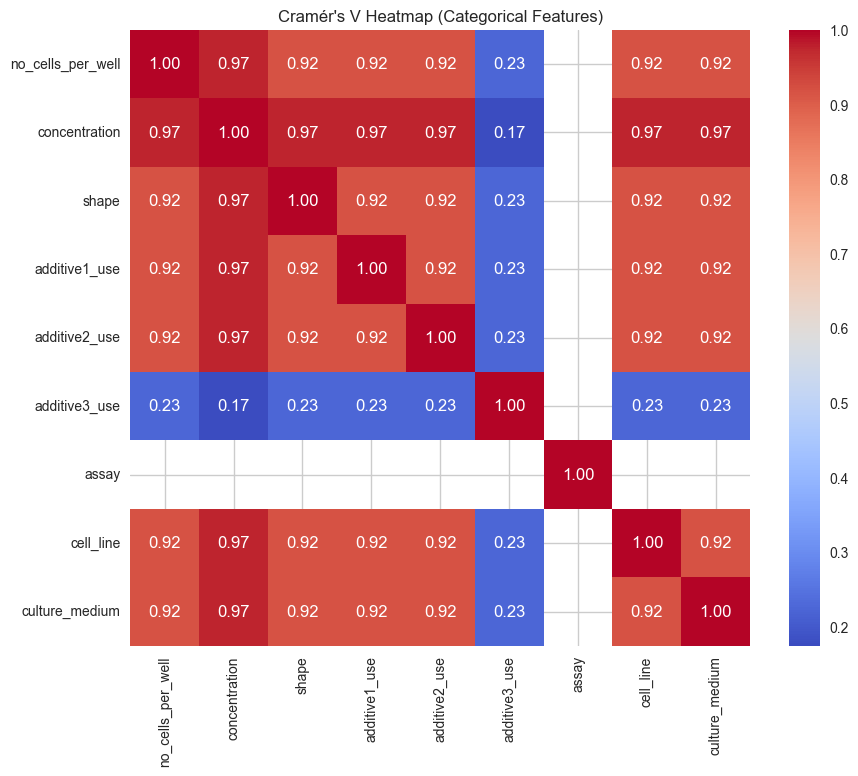

In [49]:
# Use cramer's V for categorical features between them
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))    
cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cramers_v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train_clean[col1], X_train_clean[col2])
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramér's V Heatmap (Categorical Features)")
plt.show()

## Drop Unnecessary Features

In [34]:
# mi_threshold = 0.05  # adjust as needed
# features_to_keep = mi_df[mi_df['mi_score'] >= mi_threshold]['feature'].tolist()

# X_train_clean = X_train_clean[features_to_keep]
# X_test_clean  = X_test_clean[features_to_keep]

# Machine Learning Algorithm

In [ ]:
# Recompute numerical and categorical features 
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = [col for col in categorical_cols if X_train[col].nunique() > 1]  # Remove cat features with only 1 unique value (they carry zero information)

Numerical features (6):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - incubation_time

Categorical features (9):
  - no_cells_per_well
  - concentration
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - culture_medium


In [71]:
# Preprocessing pipeline
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary"), features_cat),
    ],
    remainder="drop",
)

# Fit the preprocessor on the training data and transform both train and test sets
X_train_preprocessed = pre.fit_transform(X_train_clean)
X_test_preprocessed  = pre.transform(X_test_clean)

# Label encode the target variable for PyCaret and convert to DataFrame for easier handling ('Non_Toxic' -> 0, 'Toxic' -> 1)
label_encoder = LabelEncoder()
y_train_clean = pd.Series(label_encoder.fit_transform(y_train_clean), index=X_train_clean.index)
y_test_clean  = pd.Series(label_encoder.transform(y_test_clean), index=X_test_clean.index)    


# Get feature names after one-hot encoding
ohe_feature_names = pre.named_transformers_["cat"].get_feature_names_out(features_cat)
feature_names = features_num + list(ohe_feature_names)
print(f"Total features after preprocessing: {len(feature_names)}")

# Convert back to DataFrame for easier handling
X_train_df = pd.DataFrame(X_train_preprocessed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_preprocessed, columns=feature_names) 

# Join the target back to the preprocessed features for PyCaret
train_data = X_train_df.copy()
train_data[target] = y_train_clean.values

test_data = X_test_df.copy()
test_data[target] = y_test_clean.values


Total features after preprocessing: 19


In [72]:
# Pycaret setup
clf = setup(data=train_data,
            test_data=test_data,
            target=target,
            preprocess=False,          # data already preprocessed
            fix_imbalance=True,
            # fold=5,
            fold_strategy=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42),
            index=False,
            session_id=42)

# Compare models and select the best one based on AUC
best_model = compare_models(sort='mcc', n_select=1) # Model selection was optimized on Recall to minimize false negatives, given that misclassifying a toxic nanoparticle as safe poses unacceptable risk.
print(f"Best model: {best_model}")

,Description,Value
0,Session id,42
1,Target,toxicity
2,Target type,Binary
3,Original data shape,"(88, 20)"
4,Transformed data shape,"(88, 20)"
5,Transformed train set shape,"(61, 20)"
6,Transformed test set shape,"(27, 20)"
7,Numeric features,19


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
svm,SVM - Linear Kernel,0.9042,0.9806,0.8830,0.8779,0.8593,0.7891,0.8087,0.0012
ridge,Ridge Classifier,0.8918,0.9818,0.9000,0.8466,0.8531,0.7705,0.7919,0.0012
ada,Ada Boost Classifier,0.9000,0.9790,0.8510,0.8786,0.8480,0.7751,0.7896,0.0038
et,Extra Trees Classifier,0.8985,0.8804,0.8660,0.8630,0.8491,0.7741,0.7878,0.0096
lda,Linear Discriminant Analysis,0.8901,0.9844,0.8850,0.8502,0.8454,0.7632,0.7846,0.0014
catboost,CatBoost Classifier,0.8935,0.9665,0.8610,0.8590,0.8465,0.7663,0.7796,0.0302
lr,Logistic Regression,0.8864,0.9788,0.8180,0.8794,0.8254,0.7440,0.7636,0.0558
gbc,Gradient Boosting Classifier,0.8835,0.9575,0.8110,0.8643,0.8185,0.7347,0.7508,0.0040
rf,Random Forest Classifier,0.8769,0.9711,0.8070,0.8570,0.8083,0.7206,0.7391,0.0122
dt,Decision Tree Classifier,0.8721,0.8622,0.7730,0.8656,0.7919,0.7036,0.7235,0.0014


Best model: SGDClassifier(alpha=0.0001, average=False, class_weight=None,
              early_stopping=False, epsilon=0.1, eta0=0.001, fit_intercept=True,
              l1_ratio=0.15, learning_rate='optimal', loss='hinge',
              max_iter=1000, n_iter_no_change=5, n_jobs=-1, penalty='l2',
              power_t=0.5, random_state=42, shuffle=True, tol=0.001,
              validation_fraction=0.1, verbose=0, warm_start=False)


In [73]:
# Optimize the best model's hyperparameters using Optuna with early stopping
tuned_model = tune_model(best_model,
                         optimize='mcc',
                         search_library='optuna',
                         n_iter=200,
                         )
# Check the best hyperparameters found
print("Best hyperparameters:", tuned_model.get_params())

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9231,1.0000,1.0000,0.8333,0.9091,0.8434,0.8539
1,0.8333,0.8750,0.7500,0.7500,0.7500,0.6250,0.6250
2,0.8333,0.9688,0.7500,0.7500,0.7500,0.6250,0.6250
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
5,0.8462,0.9000,0.6000,1.0000,0.7500,0.6486,0.6928
6,0.7500,0.9375,0.5000,0.6667,0.5714,0.4000,0.4082
7,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
8,0.8333,0.9375,1.0000,0.6667,0.8000,0.6667,0.7071


Best hyperparameters: {'alpha': 2.8413537690991033e-05, 'average': False, 'class_weight': None, 'early_stopping': False, 'epsilon': 0.1, 'eta0': 0.15911694361307296, 'fit_intercept': False, 'l1_ratio': 0.4372425005347249, 'learning_rate': 'constant', 'loss': 'hinge', 'max_iter': 1000, 'n_iter_no_change': 5, 'n_jobs': -1, 'penalty': 'l2', 'power_t': 0.5, 'random_state': 42, 'shuffle': True, 'tol': 0.001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


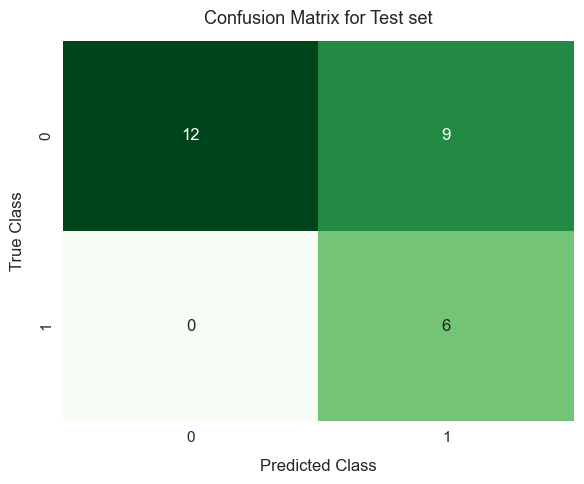

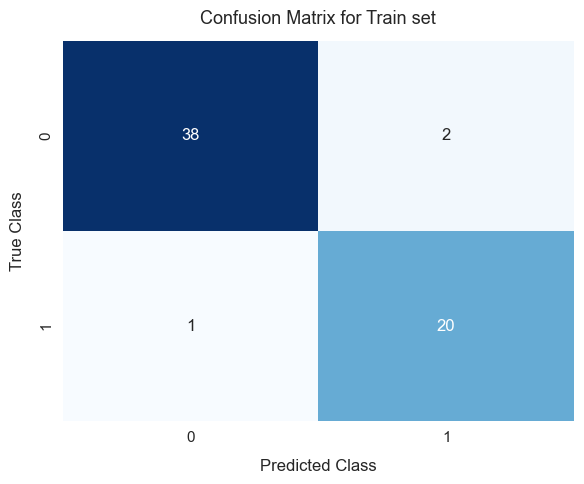

In [74]:
# Plot confusion matrix for train and test set based on the tuned model predictions
def plot_confusion_matrix(cm, title, color):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap=color, cbar=False)
    
    classes = label_encoder.classes_
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)    
    # Remove tick marks and spines
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=10)
    ax.set_ylabel('True Class', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    # plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=600, bbox_inches='tight')
    # plt.show()
    plt.show() 
# TEST SET
X_test_pred = tuned_model.predict(X_test_df)
cm_test = confusion_matrix(y_test_clean, X_test_pred)
plot_confusion_matrix(cm_test, 'Confusion Matrix for Test set', 'Greens') 
# TRAIN SET
X_train_pred = tuned_model.predict(X_train_df)
cm_train = confusion_matrix(y_train_clean, X_train_pred)
plot_confusion_matrix(cm_train, 'Confusion Matrix for Train set', 'Blues')

